In [18]:
import torch
torch.cuda.is_available()

True

In [19]:
!pip install torch torchvision matplotlib pillow

In [20]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [21]:
from google.colab import files
uploaded = files.upload()

Saving content.jpg to content (1).jpg
Saving style.jpg to style (1).jpg


In [22]:
loader = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

def load_image(path):
    image = Image.open(path)
    image = loader(image).unsqueeze(0)
    return image.to(device)

content = load_image("content.jpg")
style = load_image("style.jpg")

print("Images Loaded Successfully")

Images Loaded Successfully


In [23]:
loader = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

def load_image(path):
    image = Image.open(path)
    image = loader(image).unsqueeze(0)
    return image.to(device)

content = load_image("content.jpg")
style = load_image("style.jpg")

print("Images Loaded Successfully")

Images Loaded Successfully


In [24]:
vgg = models.vgg19(pretrained=True).features.to(device).eval()

In [25]:
def get_features(image, model):
    layers = {
        '0': 'conv1',
        '5': 'conv2',
        '10': 'conv3',
        '19': 'conv4',
        '28': 'conv5'
    }

    features = {}
    x = image

    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x

    return features

In [32]:
content_features = get_features(content, vgg)
style_features = get_features(style, vgg)

# Detach from graph
for layer in content_features:
    content_features[layer] = content_features[layer].detach()

for layer in style_features:
    style_features[layer] = style_features[layer].detach()

print("Features Extracted and Detached Successfully")

Features Extracted and Detached Successfully


In [33]:
def gram_matrix(tensor):
    batch, channels, height, width = tensor.size()

    features = tensor.view(channels, height * width)

    gram = torch.mm(features, features.t())

    return gram

In [34]:
# Compute Gram Matrices for Style Image
style_grams = {}

for layer in style_features:
    style_grams[layer] = gram_matrix(style_features[layer])

print("Style Gram Matrices Ready")

Style Gram Matrices Ready


In [35]:
# Start from content image
generated = content.clone().requires_grad_(True).to(device)

print("Generated Image Initialized")

Generated Image Initialized


In [36]:
# Define optimizer
optimizer = torch.optim.Adam([generated], lr=0.003)

# Define weights
content_weight = 1
style_weight = 1e6

print("Optimizer and Weights Set")

Optimizer and Weights Set


In [37]:
steps = 300  # You can increase later (500–1000 for better results)

for step in range(steps):

    # Extract features from generated image
    generated_features = get_features(generated, vgg)

   # -------- Content Loss --------
    content_layer = list(content_features.keys())[3]

    content_loss = torch.mean(
    (generated_features[content_layer] - content_features[content_layer]) ** 2
    )

    # -------- Style Loss --------
    style_loss = 0

    for layer in style_grams:
        generated_feature = generated_features[layer]
        generated_gram = gram_matrix(generated_feature)
        style_gram = style_grams[layer]

        _, c, h, w = generated_feature.shape

        layer_style_loss = torch.mean((generated_gram - style_gram) ** 2)
        style_loss += layer_style_loss / (c * h * w)

    # -------- Total Loss --------
    total_loss = content_weight * content_loss + style_weight * style_loss

    # -------- Backpropagation --------
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    # Show progress
    if step % 50 == 0:
        print(f"Step {step}, Total Loss: {total_loss.item()}")

Step 0, Total Loss: 2055117.875
Step 50, Total Loss: 73034.4140625
Step 100, Total Loss: 35086.12109375
Step 150, Total Loss: 25502.0
Step 200, Total Loss: 20603.77734375
Step 250, Total Loss: 17519.01171875


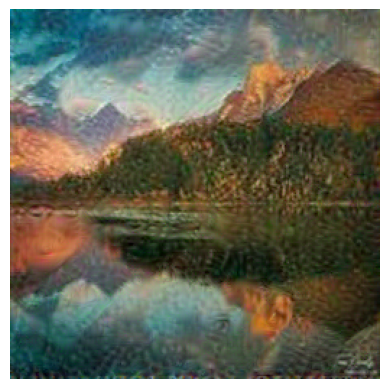

In [39]:
def imshow(tensor):
    image = tensor.cpu().clone().detach()
    image = image.squeeze(0)
    image = image.permute(1, 2, 0)
    image = torch.clamp(image, 0, 1)  # fix clipping warning
    plt.imshow(image)
    plt.axis('off')
    plt.show()

imshow(generated)

In [41]:
# Save Output
output_image = generated.cpu().clone().detach()
output_image = output_image.squeeze(0)

# Convert to PIL
unloader = transforms.ToPILImage()
image = unloader(output_image)

image.save("styled_output.jpg")

print("Image Saved Successfully")

Image Saved Successfully
